# Multivariate Analysis

Multivariate analysis examines three or more variables simultaneously to uncover non-obvious dependencies, interactions, and structural patterns within a dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


In [3]:
# Cleaning categorical text columns

df['ContractType'] = df['ContractType'].str.replace('Month to month', 'Month-to-month')
df['InternetService'] = df['InternetService'].str.replace('fiber optic', 'Fiber optic')
df['Gender'] = df['Gender'].str.capitalize()

### 1. Correlation Matrix
 A square table showing Pearson correlation coefficients ($r$) between pairs of numerical variables, bounded between $-1$ and $+1$:
 
 $$r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^n (y_i - \bar{y})^2}}$$
 
Example: 

Evaluating how customer age, account tenure, monthly charges, and total revenue co-vary across telecommunication subscribers.

#### AI/ML Usage

Used during exploratory data analysis (EDA) and feature selection to detect collinear features that cause instability in linear regression or logistic regression models.

In [4]:
# Convert Churn to binary for correlation analysis

df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [5]:
num_cols = ['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'SupportCalls', 'Churn_Numeric']
corr = df[num_cols].corr()
print("\nCorrelation Matrix:")
print(corr.round(3))


Correlation Matrix:
                  Age  TenureYears  MonthlyCharges  TotalCharges  \
Age             1.000        0.018          -0.007         0.016   
TenureYears     0.018        1.000          -0.015         0.760   
MonthlyCharges -0.007       -0.015           1.000         0.552   
TotalCharges    0.016        0.760           0.552         1.000   
SupportCalls    0.008        0.013          -0.024        -0.006   
Churn_Numeric   0.005       -0.115           0.002        -0.089   

                SupportCalls  Churn_Numeric  
Age                    0.008          0.005  
TenureYears            0.013         -0.115  
MonthlyCharges        -0.024          0.002  
TotalCharges          -0.006         -0.089  
SupportCalls           1.000          0.025  
Churn_Numeric          0.025          1.000  


### 2. Heatmap
A two-dimensional graphical representation where individual values contained in a matrix are rendered as colored cells along a continuous color scale.

Example: 

Visualizing gene expression levels across multiple biological samples or mapping high-volume customer transaction periods by day and hour.

#### AI/ML Usage

Accelerates feature diagnostic workflows by allowing data scientists to instantly spot strong correlation clusters, multicollinearity, or missing value patterns across dozens of features.

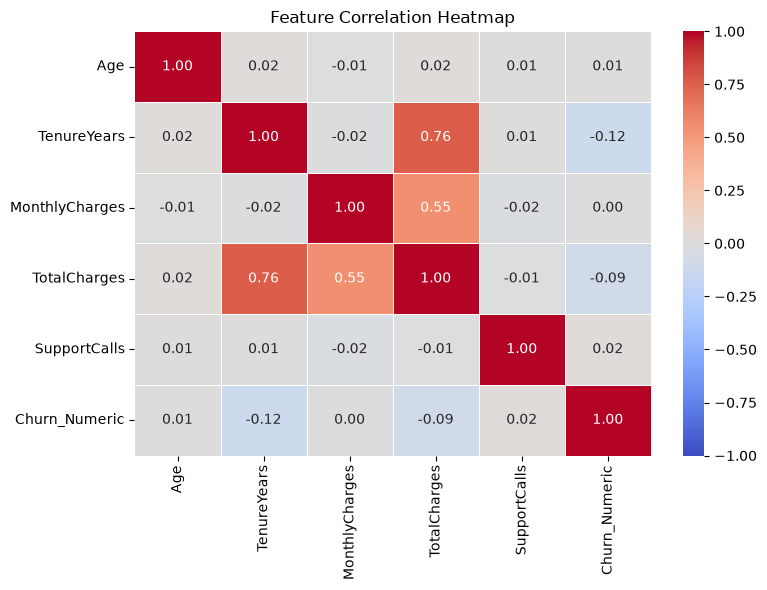

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

* Purpose: Visualizes a matrix of pairwise correlation coefficients ($r$) across all numerical variables using a color spectrum bounded between $-1.0$ and $+1.0$.

* Interpretation:

               * Warm/Red Shades ($r > 0.5$): Indicate strong positive linear relationships.

               * Cool/Blue Shades ($r < -0.5$): Indicate strong negative linear relationships.

               * Neutral/White Shades ($r \approx 0$): Indicate no linear dependency.

* Churn Dataset Findings: Highlights a strong positive correlation between TenureYears and TotalCharges ($r = 0.76$) and a moderate correlation between MonthlyCharges and TotalCharges ($r = 0.55$). Features like Age and SupportCalls show virtually zero linear correlation with billing variables ($\vert{}r\vert{} < 0.03$).

### 3. Pair Plot (Scatterplot Matrix)
A grid of pairwise scatter plots for all numerical variables in a dataset, with univariate distribution estimates (KDE or histograms) rendered along the diagonal.

Example: 

Comparing real estate attributes (price, square footage, age, distance to city center) grouped by property type.

#### AI/ML Usage
    
Helps identify non-linear relationships, multi-modal class overlaps, and spatial clustering across target classes prior to selecting linear vs. tree-based classifiers.



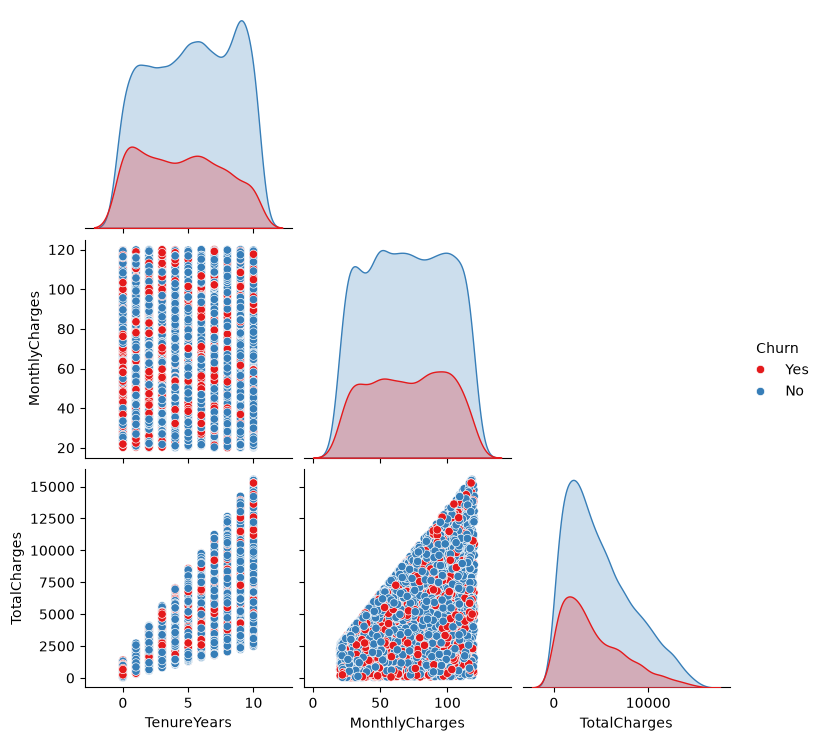

In [8]:
sns.pairplot(
    df[['TenureYears', 'MonthlyCharges', 'TotalCharges', 'Churn']], 
    hue='Churn', 
    palette='Set1', 
    corner=True
)
plt.show()


* Purpose: Generates an $n \times n$ matrix of pairwise scatter plots for continuous features, with single-variable distributions (KDE or histograms) rendered along the diagonal, segmented by a target category.

* Interpretation:

                * Off-Diagonal Plots: Show bivariate point distributions between variable pairs to identify clusters, non-linear trends, and class separation.

                * Diagonal Plots: Display class-level overlap or separation in univariate space.

* Churn Dataset Findings: Shows substantial class overlap between retained (No) and churned (Yes) customers across MonthlyCharges and TenureYears. This indicates that simple 2D linear thresholding cannot cleanly isolate churn risk.

### 4. Multiple Feature Relationships

Analyzing the simultaneous influence of three or more variables through multivariate visualizations using position, color (hue), size (size), or facets (col/row).

Example:

Mapping customer monthly spend ($y$) against tenure ($x$), segmented by contract type (color) and internet service level (subplot facet).

#### AI/ML Usage

Enables understanding of multi-way conditional dependencies to design proper segmentation logic or rule-based expert engines.

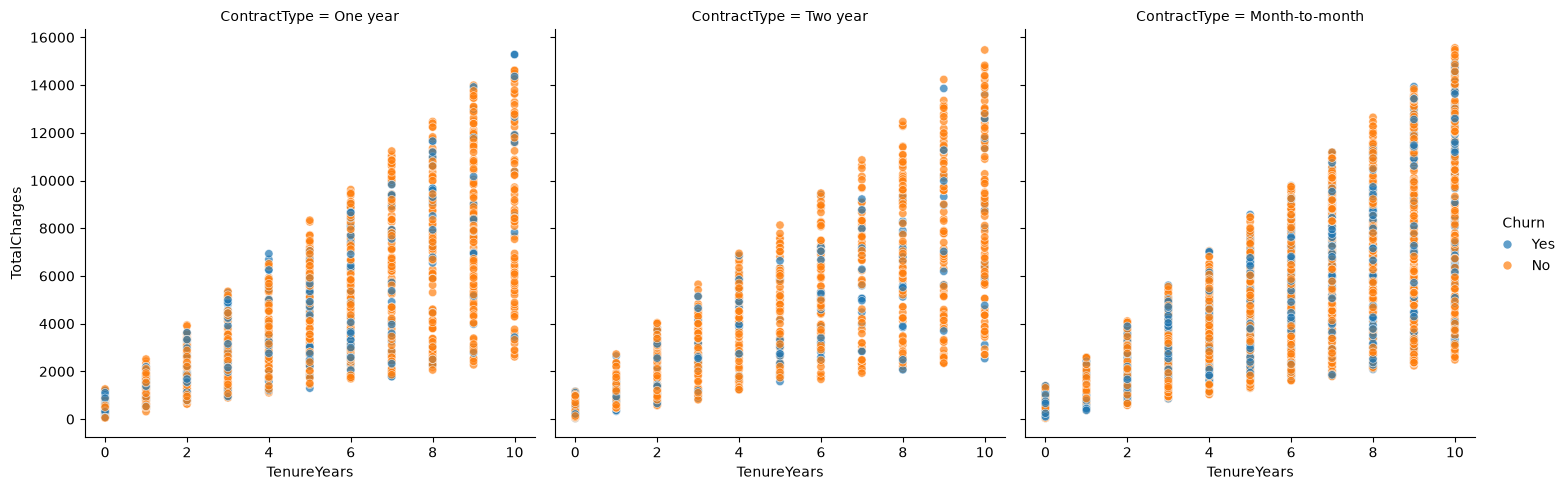

In [9]:
# Faceted scatter plot exploring 4 variables simultaneously
sns.relplot(
    data=df,
    x='TenureYears',
    y='TotalCharges',
    hue='Churn',
    col='ContractType',
    kind='scatter',
    alpha=0.7
)
plt.show()

* Purpose: Incorporates 4 to 5 features into a multi-panel visual grid by mapping attributes to the x-axis, y-axis, color (hue), marker size (size), and grid columns/rows (col/row).

* Interpretation: Evaluates how a 2D relationship changes conditionally across discrete categories (facets).

* Churn Dataset Findings: When plotting TenureYears vs. TotalCharges segmented by Churn across ContractType panels, month-to-month contracts display high churn density regardless of total spend, whereas two-year contracts show minimal churn density even at high spending levels.

### 5. Feature Interactions
A structural phenomenon where the effect of one feature ($X_1$) on a target outcome ($Y$) varies depending on the magnitude or state of a second feature ($X_2$).

Example:

The impact of customer support calls on churn probability may be negligible for low-monthly-cost users, but severe for high-monthly-cost users.

#### AI/ML Usage

Explicitly engineered into linear/logistic models via product terms ($X_1 \times X_2$) or automatically captured by non-linear algorithms like Decision Trees and Gradient Boosted Trees (XGBoost/LightGBM).

In [10]:
df['Tenure_x_Monthly'] = df['TenureYears'] * df['MonthlyCharges']
df['Calls_per_TenureYear'] = df['SupportCalls'] / (df['TenureYears'] + 1)

In [11]:
# Check interaction correlation with churn target

df['Churn_Numeric'] = (df['Churn'] == 'Yes').astype(int)
print(df[['Tenure_x_Monthly', 'Calls_per_TenureYear', 'Churn_Numeric']].corr()['Churn_Numeric'])

Tenure_x_Monthly       -0.089881
Calls_per_TenureYear    0.088432
Churn_Numeric           1.000000
Name: Churn_Numeric, dtype: float64


### 6. Numerical Feature Relationships
Statistical and spatial evaluation of joint distributions, variance structures, and linear or non-linear dependencies among continuous numerical variables.

Example:

Evaluating price elasticity curves by analyzing demand volume against unit price across distinct regional markets.

#### AI/ML Usage 

Directly informs data preprocessing steps, such as applying logarithmic transforms to skewed features, removing redundant features, or fitting Polynomial Regression models.

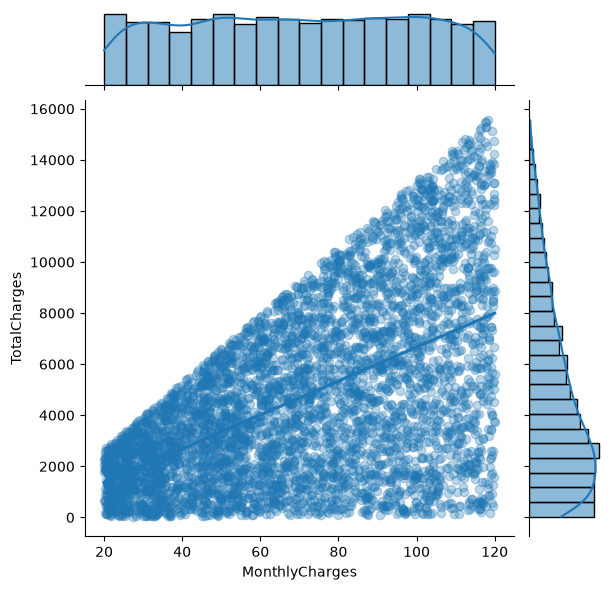

In [12]:
sns.jointplot(
    data=df, 
    x='MonthlyCharges', 
    y='TotalCharges', 
    kind='reg', 
    scatter_kws={'alpha':0.3}
)
plt.show()

* Purpose: Combines a central bivariate visualization (scatter plot, hexbin, or 2D KDE contour) with univariate marginal distributions displayed along the top and right margins.

* Interpretation:

                  * Center Plot: Maps joint distributions and global trendlines between two primary variables.

                  * Marginal Axes: Reveal whether individual variable skewness or multimodality drives cluster shapes seen in the center.

* Churn Dataset Findings: The joint plot of MonthlyCharges vs. TotalCharges reveals a distinct fan-shaped expansion. Variance in total charges increases sharply at higher monthly billing tiers due to differences in account tenure length.